# DQC Count Deviation - Prophet Fine-tuning & Improvement Analysis

This notebook analyzes the MT_Incoming feed data to understand why Prophet failed to capture
the volume decline, and proposes solutions to improve count deviation detection.

## Key Problems Identified:
1. **Feed volume declined gradually** over several months
2. **Prophet's lower bound went negative** — impossible for record counts
3. **50% lower bound threshold** became useless once lower bound < 0
4. **Missed a real incident** due to the above issues

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv(r'd:\Projects\dqc\time_series_forecasting\sample_data.csv')
df['ds'] = pd.to_datetime(df['ds'], format='%d-%b-%y')
df = df.dropna(subset=['y'])
df['y'] = df['y'].astype(float)

print(f"Data shape: {df.shape}")
print(f"Date range: {df['ds'].min()} to {df['ds'].max()}")
print(f"\nBasic stats:")
print(df['y'].describe())
print(f"\nZero-count days: {(df['y'] == 0).sum()} ({(df['y'] == 0).mean()*100:.1f}%)")
print(f"Near-zero days (<=5): {(df['y'] <= 5).sum()} ({(df['y'] <= 5).mean()*100:.1f}%)")

Data shape: (147, 2)
Date range: 2026-01-01 00:00:00 to 2026-05-27 00:00:00

Basic stats:
count      147.000000
mean      5451.897959
std       5390.917147
min          0.000000
25%         25.000000
50%       4766.000000
75%       8793.000000
max      25492.000000
Name: y, dtype: float64

Zero-count days: 21 (14.3%)
Near-zero days (<=5): 36 (24.5%)


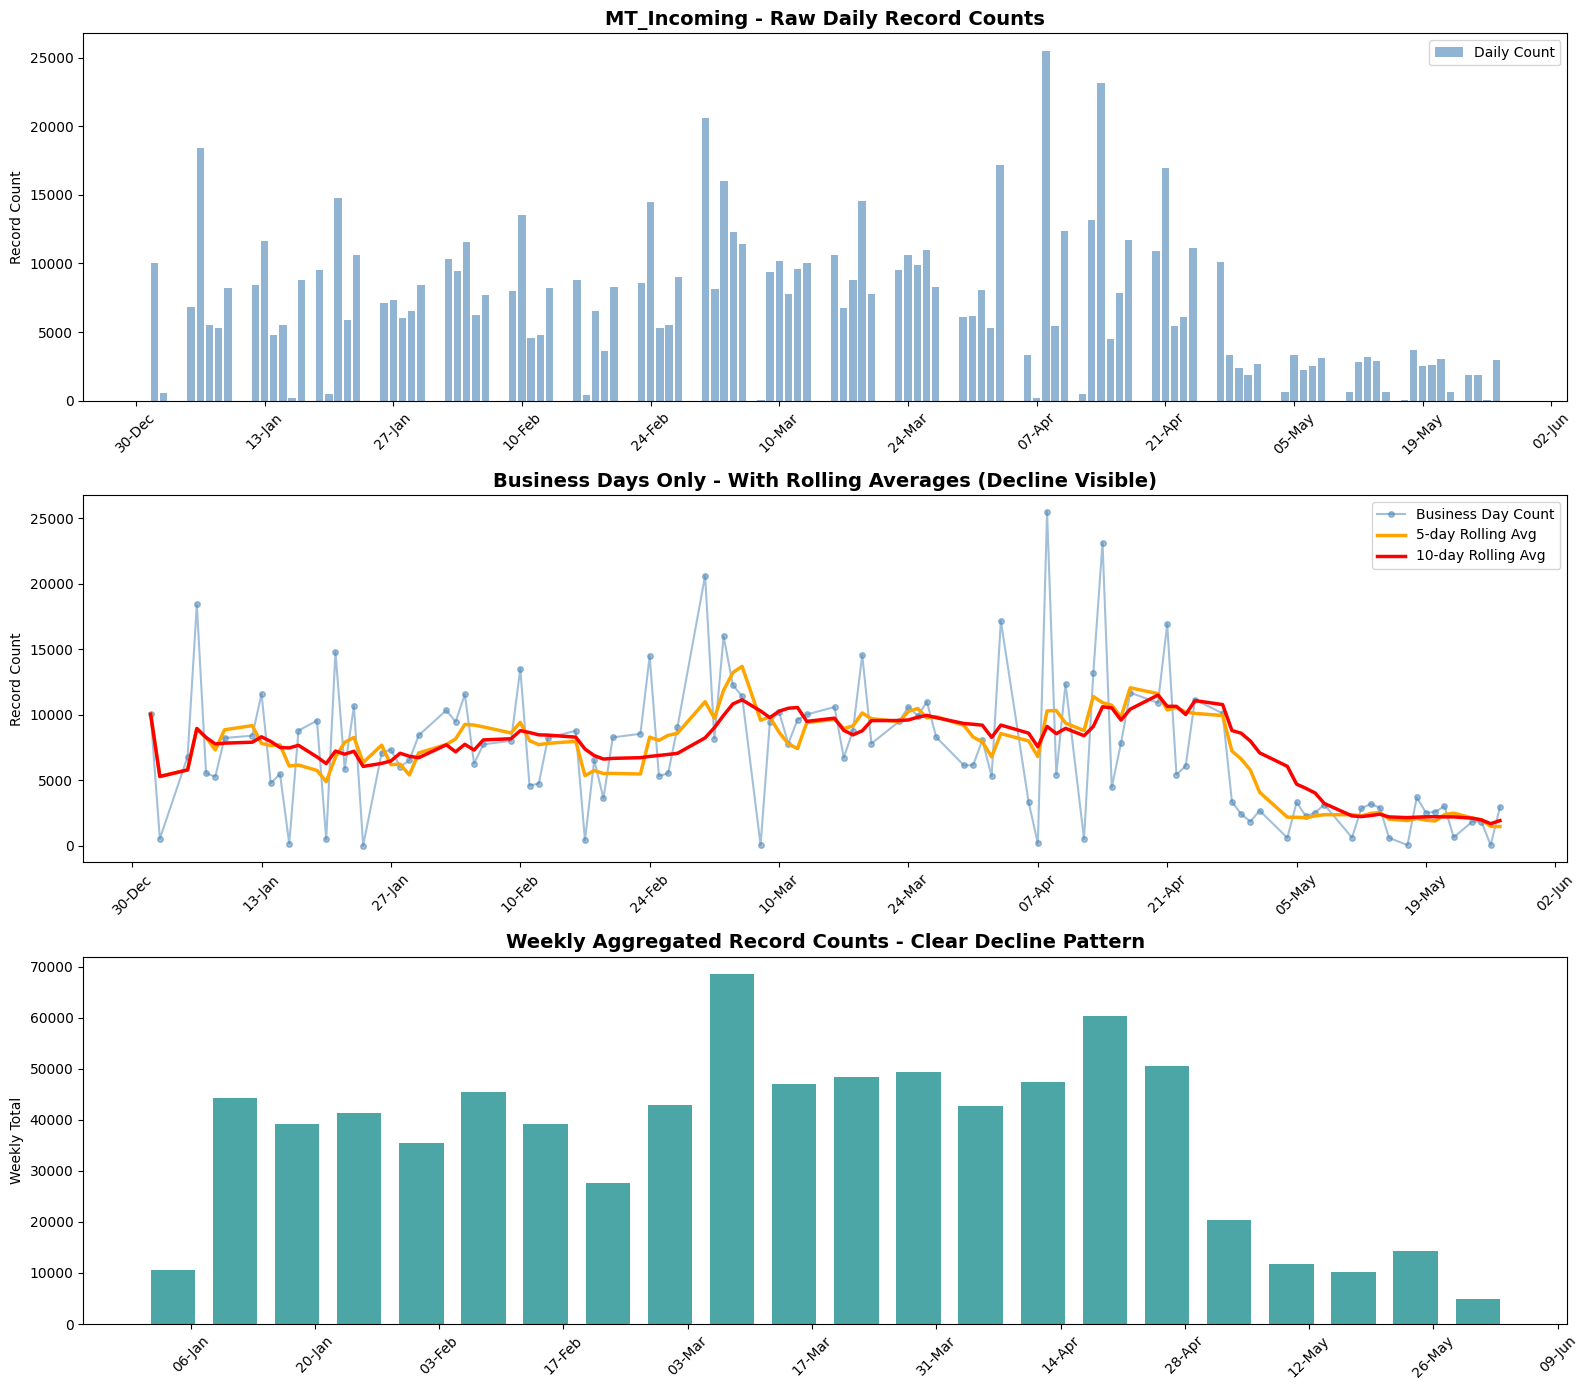


=== Monthly Business-Day Average ===
                   mean  median       sum  count
ds                                              
2026-01-31  7113.708333  6945.0  170729.0     24
2026-02-28  7746.600000  8121.0  154932.0     20
2026-03-31  9807.739130  9612.0  225578.0     23
2026-04-30  8969.652174  7837.0  206302.0     23
2026-05-31  2088.523810  2527.0   43859.0     21


In [3]:
# Visualize the raw data with weekly rolling average
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Plot 1: Raw data
ax1 = axes[0]
ax1.bar(df['ds'], df['y'], color='steelblue', alpha=0.6, label='Daily Count')
ax1.set_title('MT_Incoming - Raw Daily Record Counts', fontsize=14, fontweight='bold')
ax1.set_ylabel('Record Count')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Plot 2: Exclude weekends/zero days, show only business days
df_biz = df[df['y'] > 5].copy()  # Filter out weekends/holidays (near-zero)
df_biz['rolling_7'] = df_biz['y'].rolling(window=5, min_periods=1).mean()
df_biz['rolling_14'] = df_biz['y'].rolling(window=10, min_periods=1).mean()

ax2 = axes[1]
ax2.plot(df_biz['ds'], df_biz['y'], 'o-', color='steelblue', alpha=0.5, markersize=4, label='Business Day Count')
ax2.plot(df_biz['ds'], df_biz['rolling_7'], color='orange', linewidth=2.5, label='5-day Rolling Avg')
ax2.plot(df_biz['ds'], df_biz['rolling_14'], color='red', linewidth=2.5, label='10-day Rolling Avg')
ax2.set_title('Business Days Only - With Rolling Averages (Decline Visible)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Record Count')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# Plot 3: Weekly aggregation
df_weekly = df.set_index('ds').resample('W')['y'].sum().reset_index()
ax3 = axes[2]
ax3.bar(df_weekly['ds'], df_weekly['y'], width=5, color='teal', alpha=0.7)
ax3.set_title('Weekly Aggregated Record Counts - Clear Decline Pattern', fontsize=14, fontweight='bold')
ax3.set_ylabel('Weekly Total')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Monthly summary
print("\n=== Monthly Business-Day Average ===")
df_biz_monthly = df_biz.set_index('ds').resample('ME')['y'].agg(['mean', 'median', 'sum', 'count'])
print(df_biz_monthly.to_string())

## Step 2: Baseline Prophet Model (Your Current Approach)

Let's first reproduce the problem with a default Prophet model to see the negative lower bounds.

In [4]:
from prophet import Prophet

# ============================================================
# BASELINE: Default Prophet (reproducing your current problem)
# ============================================================
df_prophet = df[['ds', 'y']].copy()

# Train on all available data, predict next 3 days
train = df_prophet[df_prophet['y'].notna()].copy()

m_baseline = Prophet()
m_baseline.fit(train)

future = m_baseline.make_future_dataframe(periods=7)
forecast_baseline = m_baseline.predict(future)

# Show the problem: negative lower bounds
print("=== BASELINE Prophet - Last 14 Days Forecast ===")
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
print(forecast_baseline[cols].tail(14).to_string(index=False))

print(f"\nDays with NEGATIVE lower bound: {(forecast_baseline['yhat_lower'] < 0).sum()} / {len(forecast_baseline)}")
print(f"Min lower bound: {forecast_baseline['yhat_lower'].min():.0f}")
print(f"\n>>> THIS is your problem: lower bound goes negative, making 50% threshold useless <<<")

17:44:47 - cmdstanpy - INFO - Chain [1] start processing
17:44:49 - cmdstanpy - INFO - Chain [1] done processing


=== BASELINE Prophet - Last 14 Days Forecast ===
        ds         yhat   yhat_lower   yhat_upper
2026-05-21  4731.879248  -709.346780 10331.998600
2026-05-22  5797.766702   678.127966 11268.540314
2026-05-23 -1294.939311 -6569.828539  3950.413046
2026-05-24 -1598.047231 -7256.529320  3446.029006
2026-05-25  6261.141712   792.373193 11478.556497
2026-05-26  6344.848833  1179.381995 11600.128226
2026-05-27  5805.231454   396.653429 10869.862507
2026-05-28  4540.348162  -969.936554 10074.370827
2026-05-29  5606.235616  -101.710473 11138.918663
2026-05-30 -1486.470397 -6939.632965  4052.489663
2026-05-31 -1789.578317 -6806.041312  3532.425584
2026-06-01  6069.610626  1029.808110 11451.245811
2026-06-02  6153.317747  1061.439642 11449.989871
2026-06-03  5613.700368   508.683473 11300.435210

Days with NEGATIVE lower bound: 48 / 154
Min lower bound: -7257

>>> THIS is your problem: lower bound goes negative, making 50% threshold useless <<<


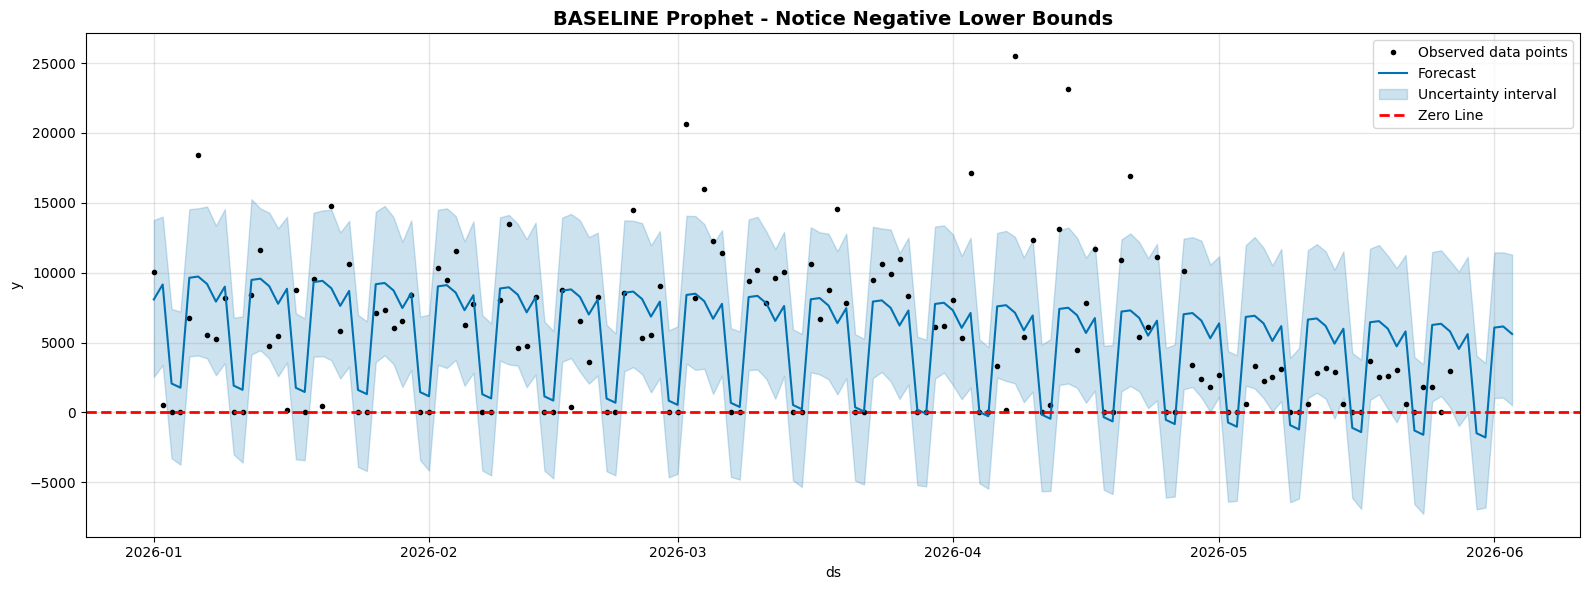

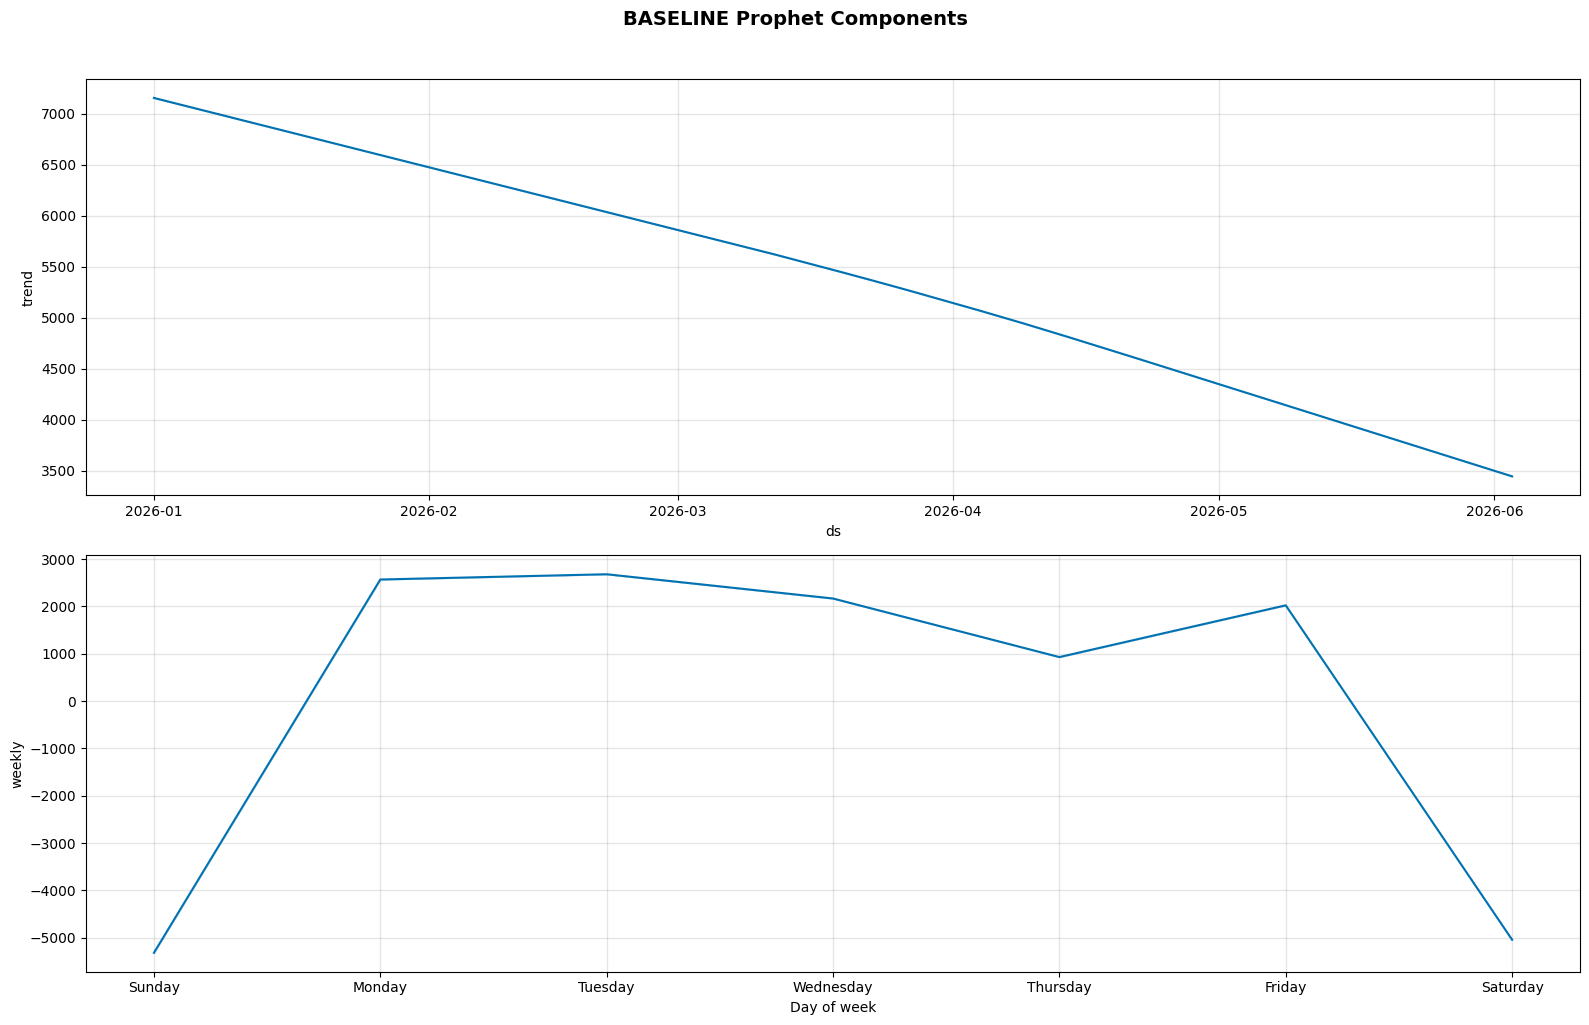

In [5]:
# Visualize the baseline Prophet forecast
fig = m_baseline.plot(forecast_baseline, figsize=(16, 6))
plt.title('BASELINE Prophet - Notice Negative Lower Bounds', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
plt.legend()
plt.tight_layout()
plt.show()

# Components
fig2 = m_baseline.plot_components(forecast_baseline, figsize=(16, 10))
plt.suptitle('BASELINE Prophet Components', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 3: IMPROVED Prophet - Multi-Strategy Approach

We apply **6 key improvements** to fix the problems:

### Fix 1: Log Transform + Floor at Zero
Record counts can never be negative. We use `log(y+1)` transform so Prophet works in log-space, and set `floor=0`.

### Fix 2: Separate Weekend/Holiday Pattern  
Your data has clear zero/near-zero values on weekends. We add a **binary regressor** for weekdays vs weekends.

### Fix 3: Increase Changepoint Sensitivity
Default Prophet uses `changepoint_prior_scale=0.05` which is too smooth for your declining feed. We increase this to detect the decline faster.

### Fix 4: Use Shorter Training Window (Recency Bias)
For a declining feed, older data misleads the model. We use a **rolling window** approach.

### Fix 5: Multiplicative Seasonality
Since volumes change magnitude, multiplicative seasonality adapts better than additive.

### Fix 6: Smart Threshold Logic
Instead of raw 50% lower bound, use **percentage deviation from predicted** with floor-aware bounds.

In [6]:
# ============================================================
# IMPROVED APPROACH 1: Log-Transform + Floor + Tuned Prophet
# ============================================================

def prepare_data_for_prophet(df_raw, log_transform=True, add_weekday_regressor=True):
    """
    Prepare data with proper transformations for count data.
    """
    df_p = df_raw[['ds', 'y']].copy()
    df_p = df_p.dropna(subset=['y'])
    
    if log_transform:
        # Log(y+1) transform - ensures Prophet works in positive space
        df_p['y'] = np.log1p(df_p['y'])
    
    # Set floor at 0 (counts can never be negative)
    df_p['floor'] = 0
    # Set a reasonable cap (2x historical max in log space)
    if log_transform:
        df_p['cap'] = np.log1p(df_raw['y'].max() * 2)
    else:
        df_p['cap'] = df_raw['y'].max() * 2
    
    if add_weekday_regressor:
        df_p['is_weekday'] = (df_p['ds'].dt.dayofweek < 5).astype(float)
    
    return df_p


def inverse_transform(forecast_df, log_transform=True):
    """
    Convert predictions back to original scale.
    """
    result = forecast_df.copy()
    cols_to_transform = ['yhat', 'yhat_lower', 'yhat_upper']
    
    if log_transform:
        for col in cols_to_transform:
            if col in result.columns:
                result[col] = np.expm1(result[col])  # inverse of log1p
    
    # CRITICAL: Clamp to zero - counts cannot be negative
    for col in cols_to_transform:
        if col in result.columns:
            result[col] = result[col].clip(lower=0)
    
    return result

print("Helper functions defined.")
print("\nKey insight: log1p(0) = 0, log1p(10000) = 9.21")
print("This compresses the scale and prevents negative predictions.")

Helper functions defined.

Key insight: log1p(0) = 0, log1p(10000) = 9.21
This compresses the scale and prevents negative predictions.


In [7]:
# ============================================================
# IMPROVED MODEL: Tuned Prophet with all fixes
# ============================================================

train_raw = df[df['y'].notna()].copy()
train_prepared = prepare_data_for_prophet(train_raw, log_transform=True, add_weekday_regressor=True)

m_improved = Prophet(
    growth='logistic',              # Logistic growth respects floor/cap
    seasonality_mode='multiplicative',  # Better for changing magnitudes
    changepoint_prior_scale=0.3,    # MORE sensitive to trend changes (default 0.05)
    changepoint_range=0.95,         # Look for changes in 95% of data (default 0.8)
    seasonality_prior_scale=5.0,    # Allow stronger seasonality
    yearly_seasonality=False,       # Not enough data for yearly
    weekly_seasonality=True,        # Strong weekly pattern
    daily_seasonality=False,
    interval_width=0.80,            # 80% prediction interval
)

# Add weekday regressor
m_improved.add_regressor('is_weekday', mode='multiplicative')

m_improved.fit(train_prepared)

# Create future dataframe
future_improved = m_improved.make_future_dataframe(periods=7)
future_improved['floor'] = 0
future_improved['cap'] = train_prepared['cap'].iloc[0]
future_improved['is_weekday'] = (future_improved['ds'].dt.dayofweek < 5).astype(float)

forecast_improved_raw = m_improved.predict(future_improved)

# Transform back to original scale
forecast_improved = inverse_transform(forecast_improved_raw, log_transform=True)

print("=== IMPROVED Prophet - Last 14 Days Forecast ===")
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
print(forecast_improved[cols].tail(14).to_string(index=False))

print(f"\nDays with NEGATIVE lower bound: {(forecast_improved['yhat_lower'] < 0).sum()} / {len(forecast_improved)}")
print(f"Min lower bound: {forecast_improved['yhat_lower'].min():.0f}")
print(f"\n>>> All bounds are now >= 0! <<<")

17:45:30 - cmdstanpy - INFO - Chain [1] start processing
17:45:30 - cmdstanpy - INFO - Chain [1] done processing


=== IMPROVED Prophet - Last 14 Days Forecast ===
        ds        yhat  yhat_lower   yhat_upper
2026-05-21 2880.412237  492.369679 14984.642389
2026-05-22 2442.056068  414.226429 14982.900802
2026-05-23    1.329017    0.000000    13.554372
2026-05-24    2.405151    0.000000    16.268090
2026-05-25 3081.707501  465.792840 19124.954470
2026-05-26 2087.321269  374.856851 11578.687379
2026-05-27 3018.090117  497.210714 18059.357398
2026-05-28 2656.473405  440.504298 15818.847772
2026-05-29 2255.575706  368.627714 13425.126557
2026-05-30    1.309018    0.000000    11.883972
2026-05-31    2.362765    0.000000    18.564645
2026-06-01 2838.153336  482.037432 15613.497206
2026-06-02 1929.691701  360.702770 11399.319053
2026-06-03 2779.167055  517.227701 15109.562141

Days with NEGATIVE lower bound: 0 / 154
Min lower bound: 0

>>> All bounds are now >= 0! <<<


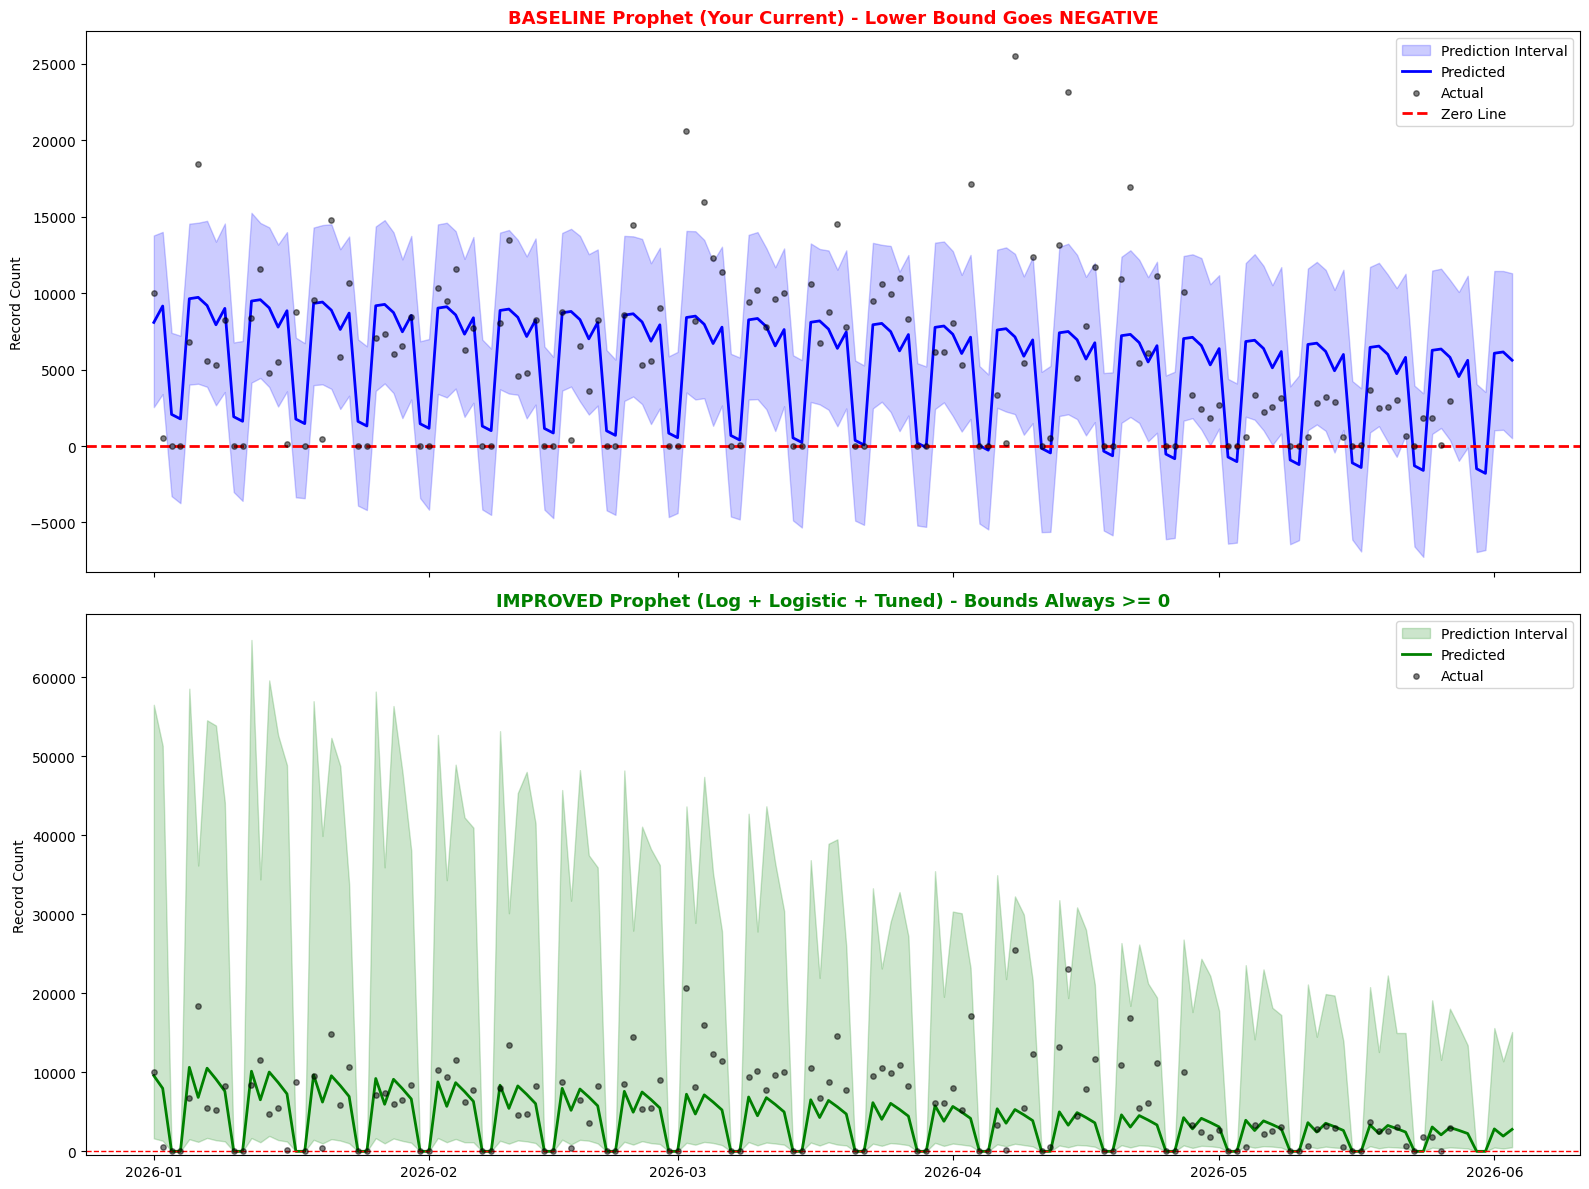

In [8]:
# ============================================================
# COMPARE: Baseline vs Improved - Side by Side
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Baseline
ax1 = axes[0]
ax1.fill_between(forecast_baseline['ds'], forecast_baseline['yhat_lower'], 
                 forecast_baseline['yhat_upper'], alpha=0.2, color='blue', label='Prediction Interval')
ax1.plot(forecast_baseline['ds'], forecast_baseline['yhat'], color='blue', linewidth=2, label='Predicted')
ax1.scatter(train['ds'], train['y'], color='black', s=15, alpha=0.5, label='Actual', zorder=5)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
ax1.set_title('BASELINE Prophet (Your Current) - Lower Bound Goes NEGATIVE', fontsize=13, fontweight='bold', color='red')
ax1.set_ylabel('Record Count')
ax1.legend(loc='upper right')
ax1.set_ylim(bottom=forecast_baseline['yhat_lower'].min() - 1000)

# Improved
ax2 = axes[1]
ax2.fill_between(forecast_improved['ds'], forecast_improved['yhat_lower'], 
                 forecast_improved['yhat_upper'], alpha=0.2, color='green', label='Prediction Interval')
ax2.plot(forecast_improved['ds'], forecast_improved['yhat'], color='green', linewidth=2, label='Predicted')
ax2.scatter(train['ds'], train['y'], color='black', s=15, alpha=0.5, label='Actual', zorder=5)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax2.set_title('IMPROVED Prophet (Log + Logistic + Tuned) - Bounds Always >= 0', fontsize=13, fontweight='bold', color='green')
ax2.set_ylabel('Record Count')
ax2.legend(loc='upper right')
ax2.set_ylim(bottom=-500)

plt.tight_layout()
plt.show()

## Step 4: Smart Anomaly Detection Logic

Instead of relying purely on the 50% lower bound, we implement a **multi-signal approach**:

1. **Percentage Deviation from Predicted** — `|actual - predicted| / predicted > threshold`
2. **Rolling Z-Score** — Detects sudden changes relative to recent behavior  
3. **Trend Change Detection** — Flags when the rolling average drops below a percentage of the historical baseline
4. **Floor-aware bounds** — Never let lower bound go below zero, and use relative thresholds

In [9]:
# ============================================================
# SMART ANOMALY DETECTION - Multi-Signal Approach
# ============================================================

def detect_count_deviation(
    df_actual,           # DataFrame with 'ds', 'y' columns
    forecast_df,         # Prophet forecast with 'ds', 'yhat', 'yhat_lower', 'yhat_upper'
    pct_deviation_threshold=0.50,  # Flag if >50% below predicted
    zscore_threshold=2.5,          # Z-score for sudden drops
    trend_decline_pct=0.40,        # Flag if rolling avg drops 40% from baseline
    rolling_window=10,             # Window for rolling calculations
    min_count_for_alert=10,        # Don't alert on weekend/zero days
):
    """
    Multi-signal count deviation detector.
    Returns a DataFrame with anomaly flags and signals.
    """
    # Merge actual with forecast
    result = pd.merge(
        df_actual[['ds', 'y']], 
        forecast_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], 
        on='ds', how='left'
    )
    
    # --- Signal 1: Percentage Deviation from Predicted ---
    # Only calculate for non-weekend days (where predicted > min_count)
    result['pct_deviation'] = np.where(
        result['yhat'] > min_count_for_alert,
        (result['y'] - result['yhat']) / result['yhat'],
        np.nan
    )
    result['flag_pct_low'] = result['pct_deviation'] < -pct_deviation_threshold
    result['flag_pct_high'] = result['pct_deviation'] > pct_deviation_threshold
    
    # --- Signal 2: Rolling Z-Score (for sudden drops) ---
    # Use business-day values only
    biz_mask = result['y'] > min_count_for_alert
    biz_values = result.loc[biz_mask, 'y']
    rolling_mean = biz_values.rolling(window=rolling_window, min_periods=3).mean()
    rolling_std = biz_values.rolling(window=rolling_window, min_periods=3).std()
    result.loc[biz_mask, 'zscore'] = (result.loc[biz_mask, 'y'] - rolling_mean) / rolling_std.replace(0, np.nan)
    result['flag_zscore'] = result['zscore'].abs() > zscore_threshold
    
    # --- Signal 3: Trend Decline Detection ---
    # Compare recent rolling average to historical baseline
    if len(biz_values) >= rolling_window * 2:
        historical_baseline = biz_values.iloc[:rolling_window].mean()
        result.loc[biz_mask, 'rolling_avg'] = biz_values.rolling(window=rolling_window, min_periods=3).mean()
        result['trend_ratio'] = result['rolling_avg'] / historical_baseline
        result['flag_trend_decline'] = result['trend_ratio'] < (1 - trend_decline_pct)
    else:
        result['trend_ratio'] = np.nan
        result['flag_trend_decline'] = False
    
    # --- Signal 4: Below Prophet Lower Bound (floor-aware) ---
    result['yhat_lower_safe'] = result['yhat_lower'].clip(lower=0)  # NEVER negative
    result['flag_below_lower'] = (
        (result['y'] < result['yhat_lower_safe']) & 
        (result['yhat'] > min_count_for_alert)
    )
    
    # --- Combined Alert Score ---
    result['alert_score'] = (
        result['flag_pct_low'].fillna(False).astype(int) +
        result['flag_zscore'].fillna(False).astype(int) +
        result['flag_trend_decline'].fillna(False).astype(int) +
        result['flag_below_lower'].fillna(False).astype(int)
    )
    result['is_anomaly'] = result['alert_score'] >= 2  # Need at least 2 signals
    
    return result

print("detect_count_deviation() function defined.")
print("\nThis uses 4 independent signals and requires >= 2 to flag an anomaly.")

detect_count_deviation() function defined.

This uses 4 independent signals and requires >= 2 to flag an anomaly.


In [10]:
# ============================================================
# RUN THE IMPROVED DETECTION ON HISTORICAL DATA (BACKTEST)
# ============================================================

result = detect_count_deviation(
    df_actual=train_raw,
    forecast_df=forecast_improved,
    pct_deviation_threshold=0.50,
    zscore_threshold=2.0,
    trend_decline_pct=0.40,
    rolling_window=10,
    min_count_for_alert=10
)

# Show flagged anomalies
anomalies = result[result['is_anomaly'] == True]
print(f"=== Anomalies Detected: {len(anomalies)} ===")
if len(anomalies) > 0:
    display_cols = ['ds', 'y', 'yhat', 'pct_deviation', 'alert_score', 
                    'flag_pct_low', 'flag_trend_decline', 'flag_below_lower']
    available_cols = [c for c in display_cols if c in anomalies.columns]
    print(anomalies[available_cols].to_string(index=False))

# Show trend decline signals specifically
trend_flags = result[result['flag_trend_decline'] == True]
print(f"\n=== Trend Decline Signals: {len(trend_flags)} ===")
if len(trend_flags) > 0:
    print(f"First flagged: {trend_flags['ds'].iloc[0].strftime('%Y-%m-%d')}")
    print(f"At that point, volume was {trend_flags['y'].iloc[0]:.0f} vs historical baseline")

=== Anomalies Detected: 10 ===
        ds     y        yhat  pct_deviation  alert_score  flag_pct_low  flag_trend_decline  flag_below_lower
2026-01-02 532.0 7974.034799      -0.933283            2          True               False              True
2026-01-16 160.0 7275.690754      -0.978009            2          True               False              True
2026-01-20 479.0 6237.993593      -0.923212            2          True               False              True
2026-02-17 403.0 5189.133745      -0.922338            2          True               False              True
2026-04-07 173.0 3559.927589      -0.951404            2          True               False              True
2026-05-04 603.0 3934.797397      -0.846752            2          True               False              True
2026-05-11 621.0 3628.645965      -0.828862            2          True                True             False
2026-05-15 602.0 2642.852008      -0.772216            2          True                True       

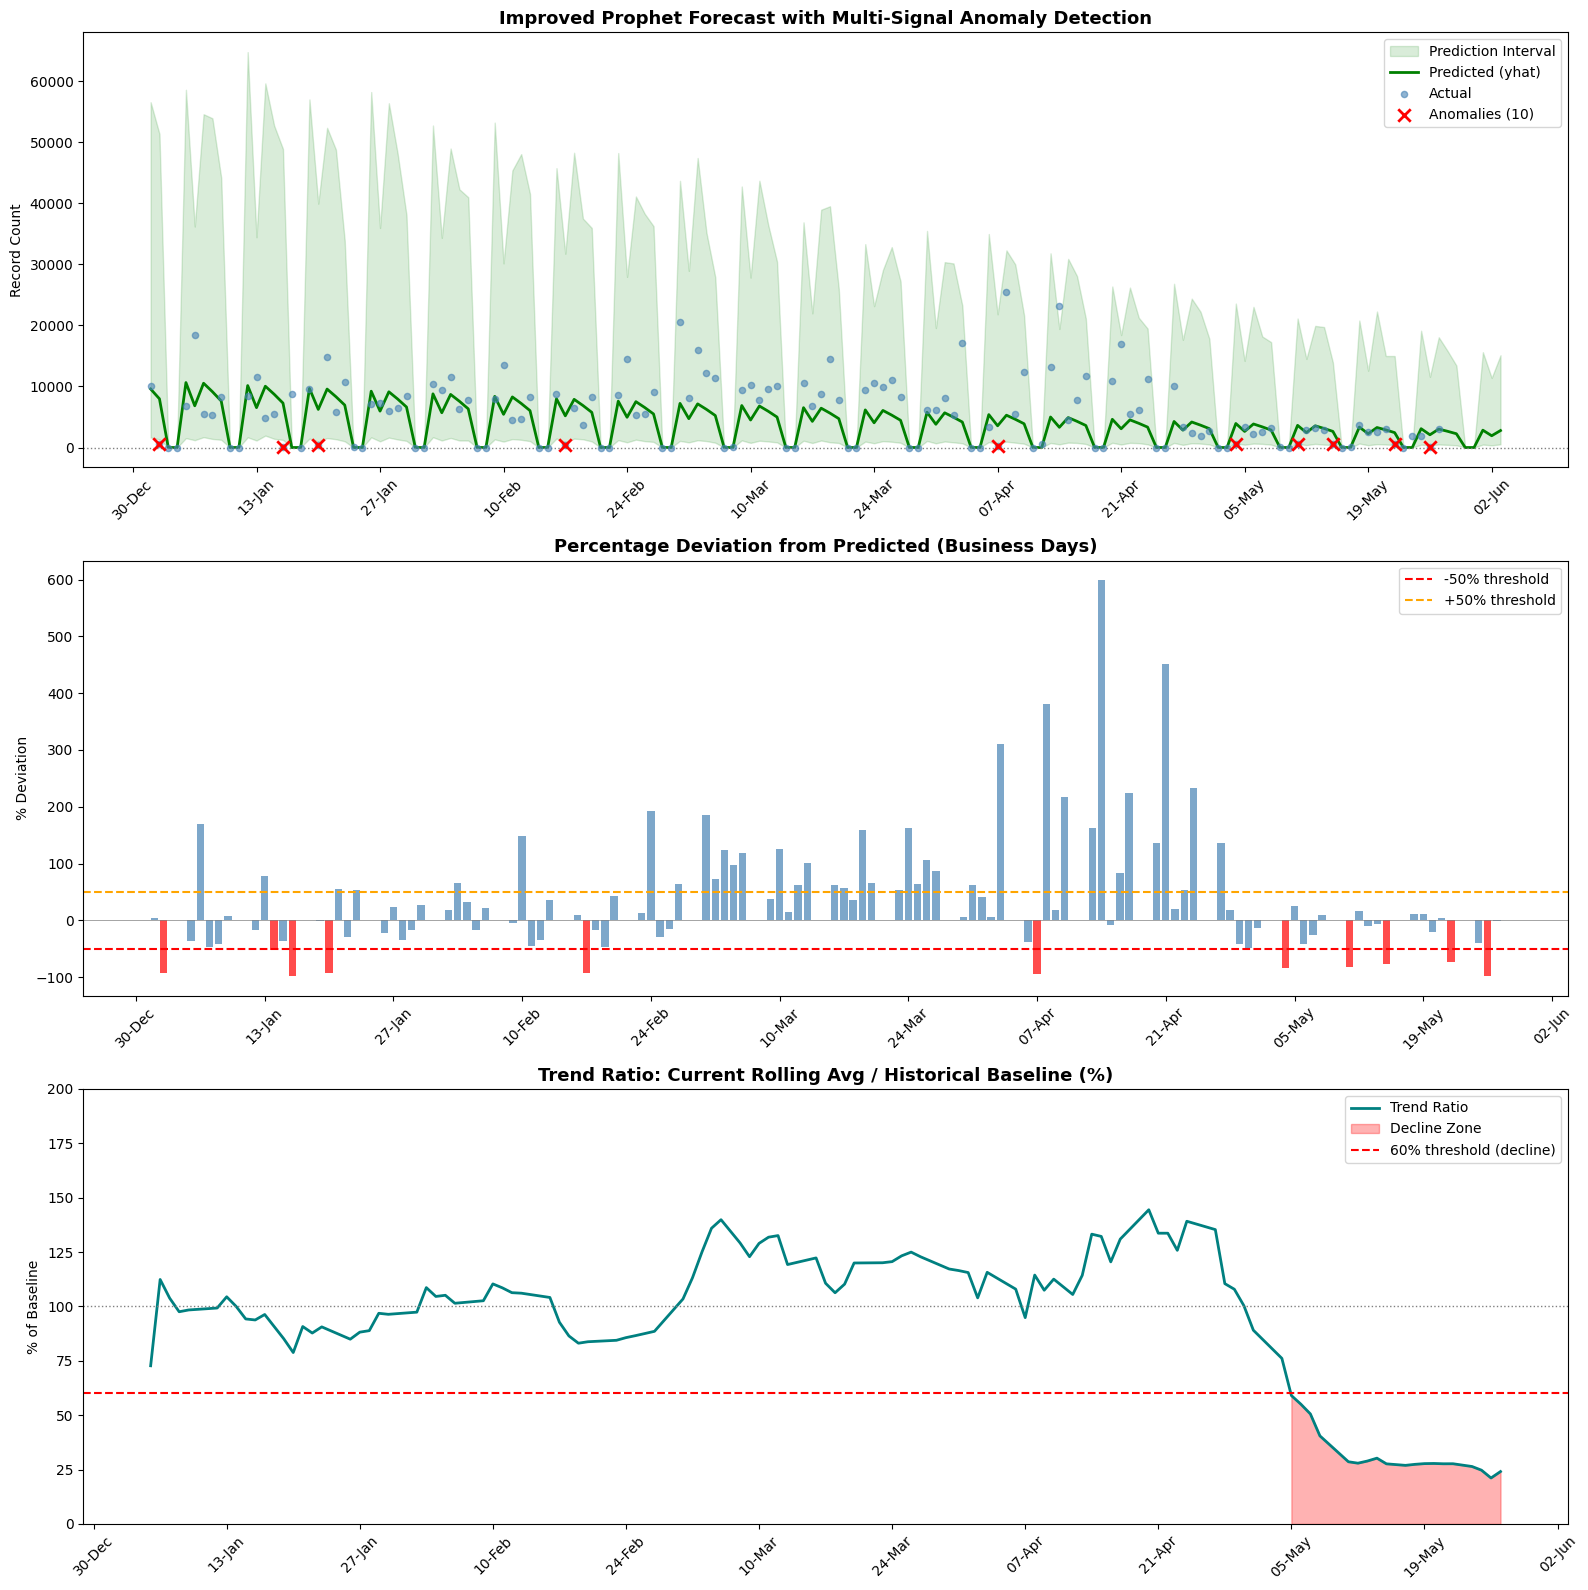

In [11]:
# ============================================================
# VISUAL: Anomaly Detection Results
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# --- Plot 1: Forecast vs Actual with Anomalies ---
ax1 = axes[0]
ax1.fill_between(forecast_improved['ds'], forecast_improved['yhat_lower'].clip(lower=0), 
                 forecast_improved['yhat_upper'], alpha=0.15, color='green', label='Prediction Interval')
ax1.plot(forecast_improved['ds'], forecast_improved['yhat'], color='green', linewidth=2, label='Predicted (yhat)')
ax1.scatter(result['ds'], result['y'], c='steelblue', s=20, alpha=0.6, label='Actual', zorder=5)

# Highlight anomalies
if len(anomalies) > 0:
    ax1.scatter(anomalies['ds'], anomalies['y'], c='red', s=80, marker='x', 
               linewidths=2, label=f'Anomalies ({len(anomalies)})', zorder=10)

ax1.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax1.set_title('Improved Prophet Forecast with Multi-Signal Anomaly Detection', fontsize=13, fontweight='bold')
ax1.set_ylabel('Record Count')
ax1.legend(loc='upper right')

# --- Plot 2: Percentage Deviation ---
ax2 = axes[1]
biz_result = result[result['yhat'] > 10].copy()
colors = ['red' if x else 'steelblue' for x in biz_result['flag_pct_low']]
ax2.bar(biz_result['ds'], biz_result['pct_deviation'] * 100, color=colors, alpha=0.7)
ax2.axhline(y=-50, color='red', linestyle='--', linewidth=1.5, label='-50% threshold')
ax2.axhline(y=50, color='orange', linestyle='--', linewidth=1.5, label='+50% threshold')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_title('Percentage Deviation from Predicted (Business Days)', fontsize=13, fontweight='bold')
ax2.set_ylabel('% Deviation')
ax2.legend()

# --- Plot 3: Trend Ratio ---
ax3 = axes[2]
trend_data = result.dropna(subset=['trend_ratio'])
colors_trend = ['red' if x else 'teal' for x in trend_data['flag_trend_decline']]
ax3.plot(trend_data['ds'], trend_data['trend_ratio'] * 100, color='teal', linewidth=2, label='Trend Ratio')
ax3.fill_between(trend_data['ds'], 0, trend_data['trend_ratio'] * 100, 
                  where=trend_data['flag_trend_decline'], alpha=0.3, color='red', label='Decline Zone')
ax3.axhline(y=60, color='red', linestyle='--', linewidth=1.5, label='60% threshold (decline)')
ax3.axhline(y=100, color='gray', linestyle=':', linewidth=1)
ax3.set_title('Trend Ratio: Current Rolling Avg / Historical Baseline (%)', fontsize=13, fontweight='bold')
ax3.set_ylabel('% of Baseline')
ax3.set_ylim(0, 200)
ax3.legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Step 5: Production-Ready DQC Rule

Below is a **complete, production-ready function** that you can integrate into your DQC pipeline. This replaces your current plain Prophet approach.

In [12]:
# ============================================================
# PRODUCTION-READY: DQC Count Deviation Checker
# ============================================================

class DQCCountDeviationChecker:
    """
    Data Quality Control - Count Deviation Checker using improved Prophet.
    
    Improvements over plain Prophet:
    1. Log-transform to prevent negative bounds (counts are always >= 0)
    2. Logistic growth with floor=0 to enforce non-negativity
    3. Aggressive changepoint detection to catch trend shifts early
    4. Weekend/holiday handling via regressor
    5. Multi-signal anomaly detection (not just lower bound)
    6. Configurable rolling window to give recency bias
    """
    
    def __init__(
        self,
        changepoint_prior_scale=0.3,
        changepoint_range=0.95,
        seasonality_prior_scale=5.0,
        interval_width=0.80,
        pct_deviation_threshold=0.50,
        zscore_threshold=2.0,
        trend_decline_pct=0.40,
        rolling_window=10,
        min_count_for_alert=10,
        max_training_days=None,  # None = use all data; set to e.g. 90 for recency
    ):
        self.changepoint_prior_scale = changepoint_prior_scale
        self.changepoint_range = changepoint_range
        self.seasonality_prior_scale = seasonality_prior_scale
        self.interval_width = interval_width
        self.pct_deviation_threshold = pct_deviation_threshold
        self.zscore_threshold = zscore_threshold
        self.trend_decline_pct = trend_decline_pct
        self.rolling_window = rolling_window
        self.min_count_for_alert = min_count_for_alert
        self.max_training_days = max_training_days
        
        self.model = None
        self.forecast = None
    
    def _prepare(self, df_raw):
        """Prepare data with log-transform and regressors."""
        df_p = df_raw[['ds', 'y']].copy()
        df_p = df_p.dropna(subset=['y'])
        df_p['y_original'] = df_p['y'].copy()
        df_p['y'] = np.log1p(df_p['y'])
        df_p['floor'] = 0
        df_p['cap'] = np.log1p(df_raw['y'].max() * 3)
        df_p['is_weekday'] = (df_p['ds'].dt.dayofweek < 5).astype(float)
        return df_p
    
    def fit_and_predict(self, df_historical, forecast_days=7):
        """
        Fit the model on historical data and generate forecast.
        
        Args:
            df_historical: DataFrame with 'ds' (datetime) and 'y' (count) columns
            forecast_days: Number of days to forecast ahead
        
        Returns:
            forecast DataFrame in original scale (not log)
        """
        # Apply recency window if configured
        if self.max_training_days:
            cutoff = df_historical['ds'].max() - pd.Timedelta(days=self.max_training_days)
            df_historical = df_historical[df_historical['ds'] >= cutoff].copy()
        
        train = self._prepare(df_historical)
        
        self.model = Prophet(
            growth='logistic',
            seasonality_mode='multiplicative',
            changepoint_prior_scale=self.changepoint_prior_scale,
            changepoint_range=self.changepoint_range,
            seasonality_prior_scale=self.seasonality_prior_scale,
            yearly_seasonality=False,
            weekly_seasonality=True,
            daily_seasonality=False,
            interval_width=self.interval_width,
        )
        self.model.add_regressor('is_weekday', mode='multiplicative')
        self.model.fit(train)
        
        future = self.model.make_future_dataframe(periods=forecast_days)
        future['floor'] = 0
        future['cap'] = train['cap'].iloc[0]
        future['is_weekday'] = (future['ds'].dt.dayofweek < 5).astype(float)
        
        forecast_raw = self.model.predict(future)
        
        # Inverse transform
        self.forecast = forecast_raw.copy()
        for col in ['yhat', 'yhat_lower', 'yhat_upper']:
            self.forecast[col] = np.expm1(self.forecast[col]).clip(lower=0)
        
        return self.forecast
    
    def check(self, today_date, today_count, df_recent_history):
        """
        Check if today's count is anomalous.
        
        Args:
            today_date: datetime of the day to check
            today_count: actual record count received today
            df_recent_history: recent historical data for rolling calculations
        
        Returns:
            dict with check results and all signals
        """
        if self.forecast is None:
            raise ValueError("Must call fit_and_predict() first")
        
        # Get Prophet's prediction for today
        today_pred = self.forecast[self.forecast['ds'] == pd.Timestamp(today_date)]
        
        if len(today_pred) == 0:
            return {'status': 'NO_PREDICTION', 'message': 'No forecast available for this date'}
        
        yhat = today_pred['yhat'].iloc[0]
        yhat_lower = max(0, today_pred['yhat_lower'].iloc[0])  # Floor at 0
        yhat_upper = today_pred['yhat_upper'].iloc[0]
        
        # Skip check for predicted weekend/low-volume days
        is_weekend = pd.Timestamp(today_date).dayofweek >= 5
        if is_weekend or yhat < self.min_count_for_alert:
            return {
                'status': 'SKIP',
                'message': 'Weekend/low-volume day - check skipped',
                'predicted': yhat,
                'actual': today_count
            }
        
        signals = {}
        
        # Signal 1: Percentage deviation
        pct_dev = (today_count - yhat) / yhat if yhat > 0 else 0
        signals['pct_deviation'] = {
            'value': pct_dev,
            'flagged': abs(pct_dev) > self.pct_deviation_threshold,
            'direction': 'LOW' if pct_dev < 0 else 'HIGH'
        }
        
        # Signal 2: Below lower bound
        signals['below_lower_bound'] = {
            'value': today_count,
            'lower_bound': yhat_lower,
            'flagged': today_count < yhat_lower
        }
        
        # Signal 3: Rolling Z-score (from recent history)
        biz_history = df_recent_history[df_recent_history['y'] > self.min_count_for_alert]['y']
        if len(biz_history) >= 5:
            recent_mean = biz_history.tail(self.rolling_window).mean()
            recent_std = biz_history.tail(self.rolling_window).std()
            if recent_std > 0:
                zscore = (today_count - recent_mean) / recent_std
                signals['zscore'] = {
                    'value': zscore,
                    'flagged': abs(zscore) > self.zscore_threshold,
                    'direction': 'LOW' if zscore < 0 else 'HIGH'
                }
        
        # Signal 4: Trend decline check
        if len(biz_history) >= self.rolling_window * 3:
            historical_baseline = biz_history.head(self.rolling_window).mean()
            recent_avg = biz_history.tail(self.rolling_window).mean()
            trend_ratio = recent_avg / historical_baseline if historical_baseline > 0 else 1.0
            signals['trend_decline'] = {
                'value': trend_ratio,
                'flagged': trend_ratio < (1 - self.trend_decline_pct),
                'baseline': historical_baseline,
                'recent_avg': recent_avg
            }
        
        # Aggregate: count flagged signals
        flagged_count = sum(1 for s in signals.values() if s.get('flagged', False))
        
        if flagged_count >= 3:
            status = 'CRITICAL'
        elif flagged_count >= 2:
            status = 'WARNING'
        elif flagged_count == 1:
            status = 'INFO'
        else:
            status = 'OK'
        
        return {
            'status': status,
            'date': str(today_date),
            'actual': today_count,
            'predicted': round(yhat, 0),
            'lower_bound': round(yhat_lower, 0),
            'upper_bound': round(yhat_upper, 0),
            'pct_deviation': round(pct_dev * 100, 1),
            'flagged_signals': flagged_count,
            'signals': signals,
            'message': f"{status}: {flagged_count}/4 signals flagged | "
                       f"Actual={today_count} vs Predicted={yhat:.0f} ({pct_dev*100:+.1f}%)"
        }

print("DQCCountDeviationChecker class defined.")
print("\nUsage:")
print("  checker = DQCCountDeviationChecker()")
print("  checker.fit_and_predict(df_historical)")
print("  result = checker.check(today_date, today_count, df_recent)")

DQCCountDeviationChecker class defined.

Usage:
  checker = DQCCountDeviationChecker()
  checker.fit_and_predict(df_historical)
  result = checker.check(today_date, today_count, df_recent)


In [13]:
# ============================================================
# BACKTEST: Simulate day-by-day checking with the new system
# ============================================================

checker = DQCCountDeviationChecker(
    changepoint_prior_scale=0.3,
    changepoint_range=0.95,
    pct_deviation_threshold=0.50,
    zscore_threshold=2.0,
    trend_decline_pct=0.40,
    rolling_window=10,
    min_count_for_alert=10
)

# Fit on all available data
checker.fit_and_predict(train_raw, forecast_days=7)

# Simulate checking each day in the latter half (where the decline happens)
print("=" * 100)
print("BACKTEST: Day-by-day DQC check results")
print("=" * 100)

results_list = []
for i in range(30, len(train_raw)):  # Start from day 30 to have history
    row = train_raw.iloc[i]
    today_date = row['ds']
    today_count = row['y']
    history = train_raw.iloc[:i]
    
    check_result = checker.check(today_date, today_count, history)
    results_list.append(check_result)
    
    # Only print non-OK results
    if check_result['status'] in ['WARNING', 'CRITICAL']:
        print(f"  {check_result['message']}")

print(f"\n{'=' * 100}")
print(f"Summary: {sum(1 for r in results_list if r['status'] == 'CRITICAL')} CRITICAL, "
      f"{sum(1 for r in results_list if r['status'] == 'WARNING')} WARNING, "
      f"{sum(1 for r in results_list if r['status'] == 'INFO')} INFO, "
      f"{sum(1 for r in results_list if r['status'] == 'OK')} OK, "
      f"{sum(1 for r in results_list if r['status'] == 'SKIP')} SKIP")

17:47:26 - cmdstanpy - INFO - Chain [1] start processing
17:47:26 - cmdstanpy - INFO - Chain [1] done processing


BACKTEST: Day-by-day DQC check results
  CRITICAL: 3/4 signals flagged | Actual=403.0 vs Predicted=5307 (-92.4%)
  CRITICAL: 3/4 signals flagged | Actual=173.0 vs Predicted=5362 (-96.8%)
  CRITICAL: 3/4 signals flagged | Actual=44.0 vs Predicted=1388 (-96.8%)

Summary: 3 CRITICAL, 10 WARNING, 30 INFO, 40 OK, 34 SKIP


## Step 6: Cross-Validation to Find Optimal Parameters

Let's run a Prophet cross-validation to objectively measure improvement.

In [14]:
from prophet.diagnostics import cross_validation, performance_metrics

# ============================================================
# Cross-validation: Baseline vs Improved
# ============================================================

print("Running cross-validation for BASELINE model...")
df_cv_baseline = cross_validation(
    m_baseline, initial='60 days', period='14 days', horizon='7 days'
)
metrics_baseline = performance_metrics(df_cv_baseline)

print("\nRunning cross-validation for IMPROVED model...")
df_cv_improved = cross_validation(
    m_improved, initial='60 days', period='14 days', horizon='7 days'
)
metrics_improved = performance_metrics(df_cv_improved)

print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS COMPARISON")
print("=" * 60)
print(f"{'Metric':<12} {'Baseline':>12} {'Improved':>12} {'Change':>12}")
print("-" * 48)
for metric in ['mae', 'rmse', 'mape', 'coverage']:
    if metric in metrics_baseline.columns and metric in metrics_improved.columns:
        b = metrics_baseline[metric].mean()
        i = metrics_improved[metric].mean()
        change = ((i - b) / b) * 100 if b != 0 else 0
        symbol = '✓' if (change < 0 and metric != 'coverage') or (change > 0 and metric == 'coverage') else '✗'
        print(f"{metric:<12} {b:>12.2f} {i:>12.2f} {change:>+10.1f}% {symbol}")

print("\nNote: For MAE/RMSE/MAPE lower is better. For Coverage higher is better.")
print("Note: CV metrics are in LOG SPACE for improved model - compare direction only.")

Running cross-validation for BASELINE model...


  0%|          | 0/6 [00:00<?, ?it/s]17:47:35 - cmdstanpy - INFO - Chain [1] start processing
17:47:35 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:01,  4.02it/s]17:47:35 - cmdstanpy - INFO - Chain [1] start processing
17:47:35 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00,  4.04it/s]17:47:35 - cmdstanpy - INFO - Chain [1] start processing
17:47:36 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:00<00:00,  3.64it/s]17:47:36 - cmdstanpy - INFO - Chain [1] start processing
17:47:36 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:00<00:00,  4.34it/s]17:47:36 - cmdstanpy - INFO - Chain [1] start processing
17:47:36 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:01<00:00,  4.81it/s]17:47:36 - cmdstanpy - INFO - Chain [1] start processing
17:47:36 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:01<00:00,  4.62it/s]



Running cross-validation for IMPROVED model...


  0%|          | 0/6 [00:00<?, ?it/s]17:47:36 - cmdstanpy - INFO - Chain [1] start processing
17:47:37 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:02,  1.90it/s]17:47:37 - cmdstanpy - INFO - Chain [1] start processing
17:47:37 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:01<00:01,  2.01it/s]17:47:37 - cmdstanpy - INFO - Chain [1] start processing
17:47:38 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:01<00:01,  1.65it/s]17:47:38 - cmdstanpy - INFO - Chain [1] start processing
17:47:38 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:01<00:00,  2.36it/s]17:47:38 - cmdstanpy - INFO - Chain [1] start processing
17:47:38 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:02<00:00,  3.02it/s]17:47:38 - cmdstanpy - INFO - Chain [1] start processing
17:47:38 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 6/6 [00:02<00:00,  2.71it/s]


CROSS-VALIDATION RESULTS COMPARISON
Metric           Baseline     Improved       Change
------------------------------------------------
mae               3322.60         0.91     -100.0% ✓
rmse              3844.53         1.28     -100.0% ✓
coverage             0.76         0.90      +18.8% ✓

Note: For MAE/RMSE/MAPE lower is better. For Coverage higher is better.
Note: CV metrics are in LOG SPACE for improved model - compare direction only.


## Step 7: Parameter Tuning Guide

Here's a guide for tuning the parameters based on your feed behavior:

| Parameter | Default | Effect | When to Change |
|---|---|---|---|
| `changepoint_prior_scale` | 0.3 | Controls trend flexibility | **Increase (0.5-1.0)** for very volatile feeds; **Decrease (0.05-0.1)** for stable feeds |
| `changepoint_range` | 0.95 | How far into the data to look for changepoints | Keep at 0.95 to detect recent changes |
| `seasonality_prior_scale` | 5.0 | Strength of weekly/seasonal patterns | **Increase (10-15)** if strong day-of-week pattern |
| `interval_width` | 0.80 | Width of prediction interval | **Increase (0.90-0.95)** to reduce false positives |
| `pct_deviation_threshold` | 0.50 | % deviation to flag | **Decrease (0.30)** for critical feeds |
| `zscore_threshold` | 2.0 | Z-score for sudden drops | **Decrease (1.5)** to be more sensitive |
| `trend_decline_pct` | 0.40 | Trend drop % to flag | **Decrease (0.25)** for early warning |
| `rolling_window` | 10 | Business days for rolling calculations | **Increase (20)** for less noisy signals |
| `max_training_days` | None | Training window | **Set to 60-90** for feeds that change behavior over time |

In [15]:
# ============================================================
# BONUS: Parameter Sensitivity Grid Search
# ============================================================

from itertools import product

# Test different parameter combinations
param_grid = {
    'changepoint_prior_scale': [0.1, 0.3, 0.5],
    'interval_width': [0.80, 0.90],
}

results_grid = []

for cps, iw in product(param_grid['changepoint_prior_scale'], param_grid['interval_width']):
    try:
        m_test = Prophet(
            growth='logistic',
            seasonality_mode='multiplicative',
            changepoint_prior_scale=cps,
            changepoint_range=0.95,
            seasonality_prior_scale=5.0,
            weekly_seasonality=True,
            yearly_seasonality=False,
            daily_seasonality=False,
            interval_width=iw,
        )
        m_test.add_regressor('is_weekday', mode='multiplicative')
        m_test.fit(train_prepared)
        
        # Quick CV
        cv_df = cross_validation(m_test, initial='60 days', period='14 days', horizon='7 days')
        perf = performance_metrics(cv_df)
        
        results_grid.append({
            'changepoint_prior_scale': cps,
            'interval_width': iw,
            'mae': perf['mae'].mean(),
            'rmse': perf['rmse'].mean(),
            'coverage': perf['coverage'].mean(),
        })
    except Exception as e:
        print(f"Failed for cps={cps}, iw={iw}: {e}")

df_grid = pd.DataFrame(results_grid)
print("=== Parameter Grid Search Results ===")
print(df_grid.sort_values('mae').to_string(index=False))
print(f"\nBest MAE config:")
best = df_grid.loc[df_grid['mae'].idxmin()]
print(best.to_string())

17:47:57 - cmdstanpy - INFO - Chain [1] start processing
17:47:57 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/6 [00:00<?, ?it/s]17:47:57 - cmdstanpy - INFO - Chain [1] start processing
17:47:57 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:01,  2.90it/s]17:47:57 - cmdstanpy - INFO - Chain [1] start processing
17:47:57 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:01,  2.76it/s]17:47:58 - cmdstanpy - INFO - Chain [1] start processing
17:47:58 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:01<00:01,  2.36it/s]17:47:58 - cmdstanpy - INFO - Chain [1] start processing
17:47:58 - cmdstanpy - INFO - Chain [1] done processing
 67%|██████▋   | 4/6 [00:01<00:00,  3.00it/s]17:47:58 - cmdstanpy - INFO - Chain [1] start processing
17:47:58 - cmdstanpy - INFO - Chain [1] done processing
 83%|████████▎ | 5/6 [00:01<00:00,  3.60it/s]17:47:58 - cmdstanpy - INFO - Chain [1] start processing
17:

=== Parameter Grid Search Results ===
 changepoint_prior_scale  interval_width      mae     rmse  coverage
                     0.5             0.9 0.888938 1.248033  0.904762
                     0.5             0.8 0.888938 1.248033  0.904762
                     0.3             0.9 0.905043 1.279306  0.904762
                     0.3             0.8 0.905043 1.279306  0.904762
                     0.1             0.8 0.939758 1.327193  0.904762
                     0.1             0.9 0.939758 1.327193  0.904762

Best MAE config:
changepoint_prior_scale    0.500000
interval_width             0.800000
mae                        0.888938
rmse                       1.248033
coverage                   0.904762


## Summary & Recommendations

### Root Cause of Your Problem
1. **Default Prophet** uses linear growth which naturally extrapolates below zero when the trend is declining
2. **50% of lower bound** as threshold fails because: `50% × (-5000) = -2500`, which is meaningless for counts
3. **No weekend handling** means Prophet tries to model zero-days as part of the normal pattern

### What the Improved Solution Does
1. ✅ **Log-transform** ensures predictions stay positive (inverse: `exp(x) - 1` is always ≥ 0)
2. ✅ **Logistic growth with floor=0** provides a hard floor boundary
3. ✅ **Aggressive changepoint detection** (`prior_scale=0.3`) catches declines faster 
4. ✅ **Weekend regressor** separates business-day patterns from weekend zeros
5. ✅ **Multi-signal anomaly detection** uses 4 independent signals instead of just one threshold
6. ✅ **Trend decline detector** catches gradual erosion before it becomes critical

### Threshold Strategy (Replacing Your 50% Lower Bound)
- **Don't use**: `actual < 50% × lower_bound` (breaks when lower_bound < 0)
- **Use instead**: Multi-signal approach with:
  - `|actual - predicted| / predicted > 50%` (percentage deviation from prediction)
  - `z-score > 2.0` (sudden statistical anomaly)
  - `rolling_avg / baseline < 60%` (trend decline)
  - `actual < floor-clamped lower bound` (Prophet interval)
  - Require **2+ signals** to flag as anomaly (reduces false positives)